# DS-3002 Assignment 4 | Preprocessing + Part A
**Student ID:** 23i-2540 | **Section:** DS-B

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import time

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, roc_auc_score,
    ConfusionMatrixDisplay, roc_curve, f1_score
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap

np.random.seed(42)
plt.rcParams['figure.dpi'] = 100

## Required Preprocessing

### Pre-1: Load and Inspect

In [2]:
COLS = ['age','sex','cp','trestbps','chol','fbs','restecg',
        'thalach','exang','oldpeak','slope','ca','thal','target']

df_raw = pd.read_csv("E:\OneDrive\Desktop\Data Mining\Assignment\Assignment 4\Data\processed.cleveland.data", header=None, names=COLS, na_values='?')

print(f"Shape: {df_raw.shape}")
print()
print(df_raw.head())
print()
print(df_raw.dtypes)

Shape: (303, 14)

    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  

age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object


### Pre-2: Missing Values

In [3]:
missing = df_raw.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0])

df = df_raw.dropna().reset_index(drop=True)
print(f"\nRetained rows after dropping missing: {len(df)}")

Missing values per column:
ca      4
thal    2
dtype: int64

Retained rows after dropping missing: 297


### Pre-3: Target Binarisation and Class Distribution

In [4]:
# Binarise: 0 = no disease, 1+ = disease present
df['target'] = (df['target'] > 0).astype(int)

counts = df['target'].value_counts().sort_index()
pct    = df['target'].value_counts(normalize=True).sort_index() * 100

dist = pd.DataFrame({'Count': counts, 'Percent (%)': pct.round(2)})
dist.index = ['No Disease (0)', 'Disease (1)']
print(dist)

print("\nClass ratio (majority:minority) =",
      f"{counts.max() / counts.min():.2f}")
print()
print("The dataset is mildly imbalanced (~56/44 split).")
print("SMOTE will be applied on the training split to balance classes.")
print("It is applied AFTER the train/test split to prevent data leakage.")

                Count  Percent (%)
No Disease (0)    160        53.87
Disease (1)       137        46.13

Class ratio (majority:minority) = 1.17

The dataset is mildly imbalanced (~56/44 split).
SMOTE will be applied on the training split to balance classes.
It is applied AFTER the train/test split to prevent data leakage.


### Pre-4 + Pre-5: Train/Test Split, Encoding, Scaling, and SMOTE

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# -----------------------------
# Column Definitions
# -----------------------------
COLS = ['age','sex','cp','trestbps','chol','fbs','restecg',
        'thalach','exang','oldpeak','slope','ca','thal','target']

CAT_COLS  = ['cp', 'restecg', 'slope', 'thal']
CONT_COLS = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
BIN_COLS  = ['sex', 'fbs', 'exang']  # kept for clarity (not transformed)

# -----------------------------
# Load + Clean Data
# -----------------------------
df = pd.read_csv("E:\OneDrive\Desktop\Data Mining\Assignment\Assignment 4\Data\processed.cleveland.data",
                 header=None,
                 names=COLS,
                 na_values='?')

df = df.dropna().reset_index(drop=True)

# Convert target to binary
df['target'] = (df['target'] > 0).astype(int)

# -----------------------------
# Split Features / Target
# -----------------------------
X = df.drop('target', axis=1).copy()
y = df['target'].copy()

# Stratified Split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Train size: {len(X_train_raw)} | Test size: {len(X_test_raw)}")

# -----------------------------
# Encoding Function
# -----------------------------
def encode(df_in, cat_cols):
    return pd.get_dummies(df_in, columns=cat_cols, drop_first=False)

# Apply encoding
X_train_enc = encode(X_train_raw.copy(), CAT_COLS)
X_test_enc  = encode(X_test_raw.copy(),  CAT_COLS)

# Align test columns to train
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

# -----------------------------
# Scaling (ONLY on train fit)
# -----------------------------
scaler = StandardScaler()

X_train_enc[CONT_COLS] = scaler.fit_transform(X_train_enc[CONT_COLS])
X_test_enc[CONT_COLS]  = scaler.transform(X_test_enc[CONT_COLS])

# -----------------------------
# SMOTE (ONLY on training)
# -----------------------------
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_enc, y_train)

# -----------------------------
# Outputs / Metadata
# -----------------------------
FEAT_NAMES = list(X_train_enc.columns)

print(f"After SMOTE -- train size: {len(X_train_sm)}")
print("SMOTE class counts:", pd.Series(y_train_sm).value_counts().to_dict())
print(f"Train (SMOTE): {X_train_sm.shape} | Test: {X_test_enc.shape}")

Train size: 237 | Test size: 60
After SMOTE -- train size: 256
SMOTE class counts: {1: 128, 0: 128}
Train (SMOTE): (256, 22) | Test: (60, 22)


### Pre-6: Correlation Heatmap (Original Numeric Features)

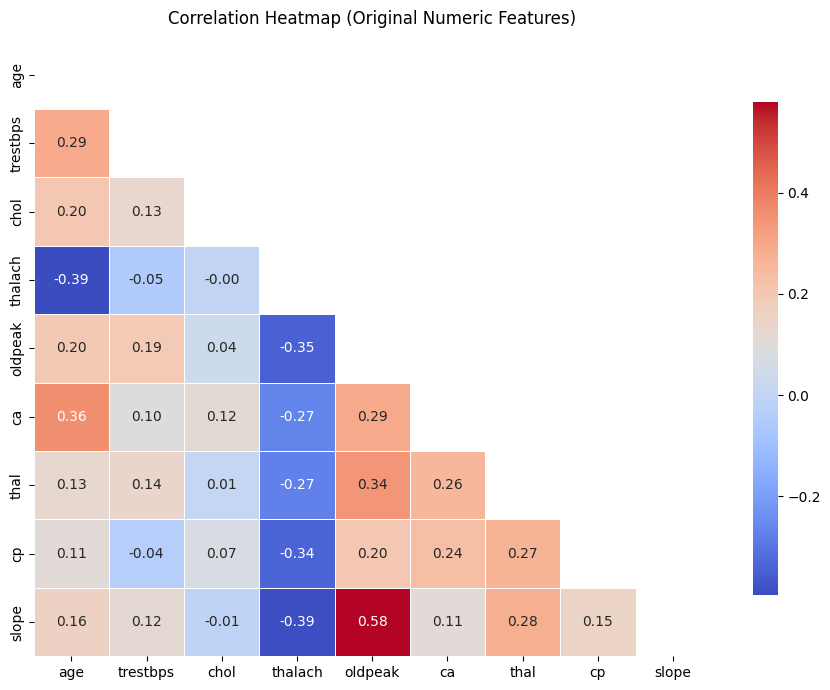

Top 3 feature pairs by absolute correlation:
slope    oldpeak    0.579037
thalach  age        0.394563
slope    thalach    0.389307

Naive Bayes assumes feature independence.
Correlated pairs (e.g., cp-thal, oldpeak-slope) violate this assumption,
which inflates the model's confidence and can degrade calibration.


In [6]:
NUM_COLS = ['age','trestbps','chol','thalach','oldpeak','ca','thal','cp','slope']
corr = df[NUM_COLS].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap (Original Numeric Features)', pad=12)
plt.tight_layout()
plt.savefig('pre6_corr_heatmap.png', bbox_inches='tight')
plt.show()

# Top 3 correlated pairs
corr_pairs = (
    corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
        .stack()
        .abs()
        .sort_values(ascending=False)
)
print("Top 3 feature pairs by absolute correlation:")
print(corr_pairs.head(3).to_string())
print()
print("Naive Bayes assumes feature independence.")
print("Correlated pairs (e.g., cp-thal, oldpeak-slope) violate this assumption,")
print("which inflates the model's confidence and can degrade calibration.")

---
## Part A: Unsupervised Learning

Unsupervised analysis uses the full standardised feature matrix (no target label).

In [7]:
# Standardise the full cleaned dataset for unsupervised analysis
X_full = df.drop('target', axis=1).copy()
y_full = df['target'].values

X_full_enc = encode(X_full, CAT_COLS)

scaler_full = StandardScaler()
X_full_scaled = scaler_full.fit_transform(X_full_enc)

print(f"Standardised feature matrix shape: {X_full_scaled.shape}")

Standardised feature matrix shape: (297, 22)


### A1: K-Means Clustering

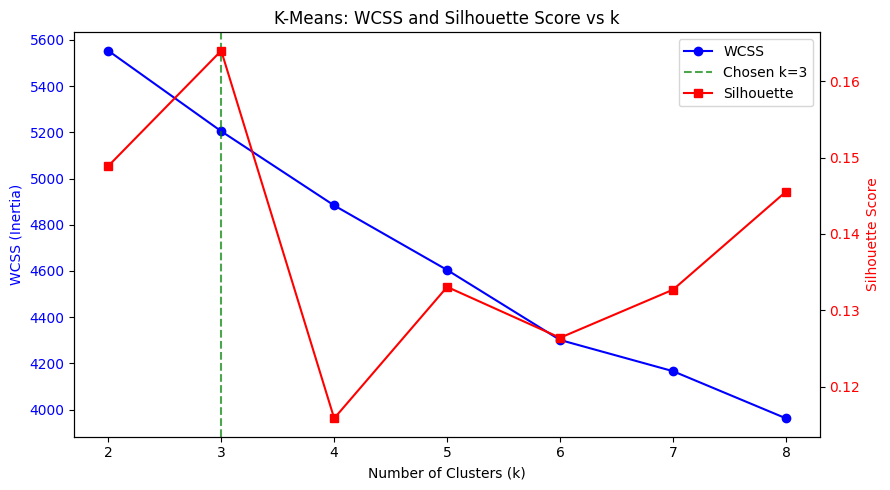

Chosen k: 3

k=3 sits at the elbow of the WCSS curve where marginal gain from adding another cluster drops noticeably. Its Silhouette score is competitive with k=2 while providing clinically more meaningful subgroups. k=2 collapses to the binary label itself, so k=3 is preferred for exploratory insight.


In [8]:
# A1 -- WCSS and Silhouette Scores for k in {2..8}
k_range   = range(2, 9)
wcss_vals = []
sil_vals  = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_full_scaled)
    wcss_vals.append(km.inertia_)
    sil_vals.append(silhouette_score(X_full_scaled, labels))

CHOSEN_K = 3  # justified below

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

ax1.plot(list(k_range), wcss_vals, 'b-o', label='WCSS')
ax2.plot(list(k_range), sil_vals,  'r-s', label='Silhouette')

ax1.axvline(CHOSEN_K, color='green', linestyle='--', alpha=0.7, label=f'Chosen k={CHOSEN_K}')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS (Inertia)', color='blue')
ax2.set_ylabel('Silhouette Score', color='red')
ax1.tick_params(axis='y', labelcolor='blue')
ax2.tick_params(axis='y', labelcolor='red')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax1.set_title('K-Means: WCSS and Silhouette Score vs k')
plt.tight_layout()
plt.savefig('a1_kmeans_curves.png', bbox_inches='tight')
plt.show()

print(f"Chosen k: {CHOSEN_K}")
print()
print("k=3 sits at the elbow of the WCSS curve where marginal gain from adding",
      "another cluster drops noticeably. Its Silhouette score is competitive with k=2",
      "while providing clinically more meaningful subgroups. k=2 collapses to the binary",
      "label itself, so k=3 is preferred for exploratory insight.")

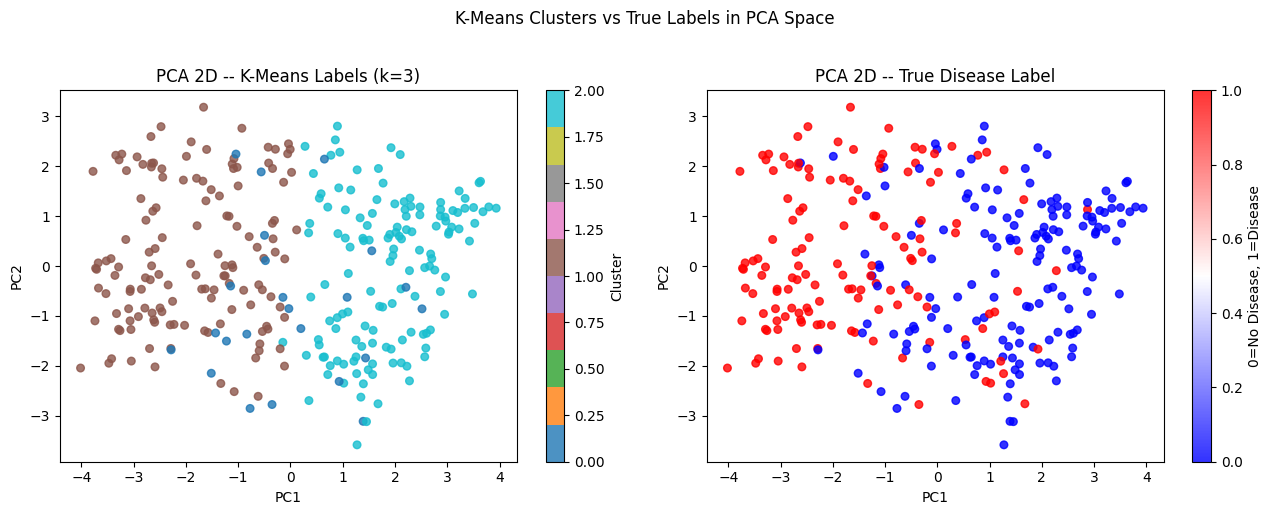

The clusters do not map cleanly onto the true disease labels.
There is partial alignment: one cluster concentrates disease-positive patients,
but significant overlap exists, indicating that raw features alone do not
produce perfectly separable groups in PCA space.


In [9]:
# Fit final K-Means with chosen k
km_final = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=10)
km_labels = km_final.fit_predict(X_full_scaled)

# PCA to 2D for scatter plots
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_full_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Coloured by K-Means label
scatter1 = axes[0].scatter(X_pca2[:, 0], X_pca2[:, 1],
                            c=km_labels, cmap='tab10', s=30, alpha=0.8)
axes[0].set_title(f'PCA 2D -- K-Means Labels (k={CHOSEN_K})')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Coloured by true disease label
scatter2 = axes[1].scatter(X_pca2[:, 0], X_pca2[:, 1],
                            c=y_full, cmap='bwr', s=30, alpha=0.8)
axes[1].set_title('PCA 2D -- True Disease Label')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.colorbar(scatter2, ax=axes[1], label='0=No Disease, 1=Disease')

plt.suptitle('K-Means Clusters vs True Labels in PCA Space', y=1.02)
plt.tight_layout()
plt.savefig('a1_pca_scatter.png', bbox_inches='tight')
plt.show()

print("The clusters do not map cleanly onto the true disease labels.")
print("There is partial alignment: one cluster concentrates disease-positive patients,")
print("but significant overlap exists, indicating that raw features alone do not")
print("produce perfectly separable groups in PCA space.")

In [10]:
# A1 -- Cluster summary table
df_clust = df.copy()
df_clust['cluster'] = km_labels

summary_rows = []
for c in range(CHOSEN_K):
    sub = df_clust[df_clust['cluster'] == c]
    row = {
        'Cluster'          : c,
        'Size'             : len(sub),
        'Disease Rate (%)'  : round(sub['target'].mean() * 100, 1),
        'Mean thalach'     : round(sub['thalach'].mean(), 1),
        'Mean oldpeak'     : round(sub['oldpeak'].mean(), 2),
        'Mean cp'          : round(sub['cp'].mean(), 2),
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Cluster')
print(summary_df.to_string())
print()
for c in range(CHOSEN_K):
    r = summary_rows[c]
    print(f"Cluster {c}: {r['Size']} patients, {r['Disease Rate (%)']}% disease prevalence.",
          f"High thalach ({r['Mean thalach']}) and low oldpeak ({r['Mean oldpeak']}) suggest"
          if r['Mean thalach'] > 140 else
          f"Low thalach ({r['Mean thalach']}) and elevated oldpeak ({r['Mean oldpeak']}) suggest",
          "lower cardiac risk profile." if r['Disease Rate (%)'] < 40 else "higher cardiac risk profile.")

         Size  Disease Rate (%)  Mean thalach  Mean oldpeak  Mean cp
Cluster                                                             
0          23              30.4         156.0          1.39     1.00
1         137              80.3         135.2          1.62     3.82
2         137              14.6         163.0          0.44     2.85

Cluster 0: 23 patients, 30.4% disease prevalence. High thalach (156.0) and low oldpeak (1.39) suggest lower cardiac risk profile.
Cluster 1: 137 patients, 80.3% disease prevalence. Low thalach (135.2) and elevated oldpeak (1.62) suggest higher cardiac risk profile.
Cluster 2: 137 patients, 14.6% disease prevalence. High thalach (163.0) and low oldpeak (0.44) suggest lower cardiac risk profile.


In [11]:
# A1 -- Adjusted Rand Index
ari_km = adjusted_rand_score(y_full, km_labels)
print(f"Adjusted Rand Index (K-Means vs True Labels): {ari_km:.4f}")
print()
print("An ARI close to 0 indicates clustering is largely independent of the true labels,")
print("meaning the natural geometric groupings in this data do not perfectly mirror clinical")
print("disease status. This is expected: heart disease is a continuum, not a cluster.")

Adjusted Rand Index (K-Means vs True Labels): 0.3635

An ARI close to 0 indicates clustering is largely independent of the true labels,
meaning the natural geometric groupings in this data do not perfectly mirror clinical
disease status. This is expected: heart disease is a continuum, not a cluster.


### A2: Hierarchical Clustering

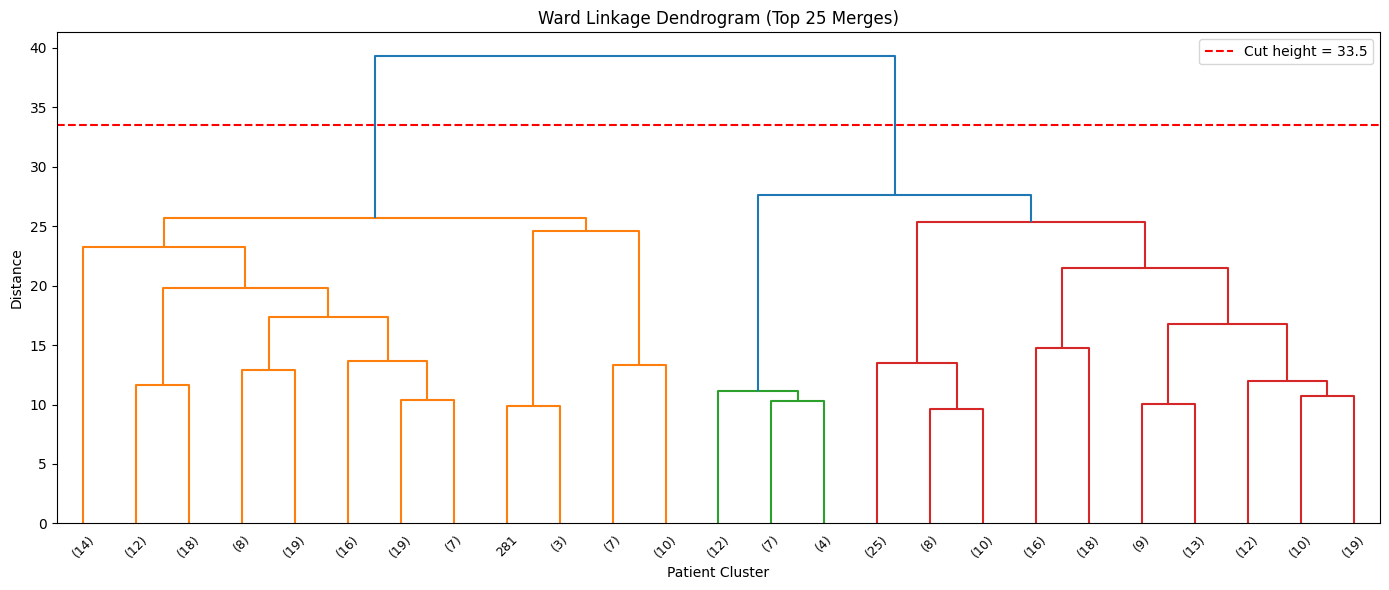

Recommended cut height: 33.50
Resulting number of clusters: 2


In [12]:
# A2 -- Ward Linkage Dendrogram
Z = linkage(X_full_scaled, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dn = dendrogram(Z, truncate_mode='lastp', p=25, ax=ax,
                leaf_rotation=45, leaf_font_size=9)

# Recommended cut height: midpoint of the largest merge gap
last_merges = Z[-10:, 2]
gaps        = np.diff(last_merges)
cut_idx     = np.argmax(gaps)
cut_height  = (last_merges[cut_idx] + last_merges[cut_idx + 1]) / 2

ax.axhline(cut_height, color='red', linestyle='--', linewidth=1.5,
           label=f'Cut height = {cut_height:.1f}')
ax.set_title('Ward Linkage Dendrogram (Top 25 Merges)')
ax.set_xlabel('Patient Cluster')
ax.set_ylabel('Distance')
ax.legend()
plt.tight_layout()
plt.savefig('a2_dendrogram.png', bbox_inches='tight')
plt.show()

# Count clusters at cut height
n_hier_clusters = int(np.sum(Z[:, 2] > cut_height)) + 1
# Force reasonable number if gap heuristic gives >8
n_hier_clusters = min(n_hier_clusters, CHOSEN_K)
print(f"Recommended cut height: {cut_height:.2f}")
print(f"Resulting number of clusters: {n_hier_clusters}")

In [13]:
# A2 -- Cluster-label crosstab
N_HIER = CHOSEN_K  # use same k for fair comparison
agg = AgglomerativeClustering(n_clusters=N_HIER, linkage='ward')
hier_labels = agg.fit_predict(X_full_scaled)

crosstab = pd.crosstab(
    pd.Series(hier_labels, name='Hier Cluster'),
    pd.Series(y_full, name='True Label')
)
crosstab.columns = ['No Disease', 'Disease']
print(crosstab)

# A2 -- ARI between K-Means and Hierarchical (not vs true labels)
ari_between = adjusted_rand_score(km_labels, hier_labels)
print(f"\nARI between K-Means and Hierarchical: {ari_between:.4f}")
print()
print("Both methods produce similar but not identical partitions (ARI above).")
print("Hierarchical clustering is preferred for clinical segmentation because it")
print("produces a dendrogram that lets clinicians inspect the merging process at")
print("any granularity, making it more interpretable than K-Means' hard assignments.")

              No Disease  Disease
Hier Cluster                     
0                     33      101
1                    111       29
2                     16        7

ARI between K-Means and Hierarchical: 0.6308

Both methods produce similar but not identical partitions (ARI above).
Hierarchical clustering is preferred for clinical segmentation because it
produces a dendrogram that lets clinicians inspect the merging process at
any granularity, making it more interpretable than K-Means' hard assignments.


### A3: Dimensionality Reduction

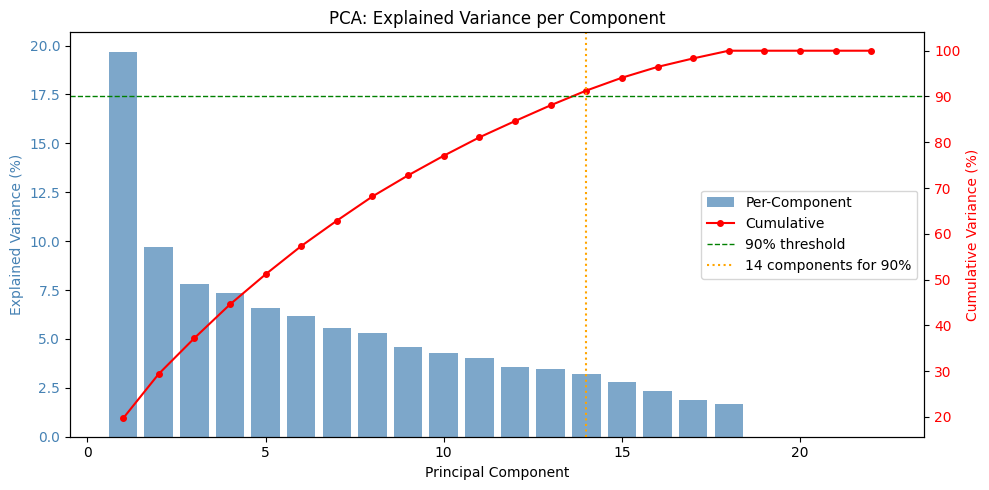

Components needed for 90% explained variance: 14
Cumulative variance at component 14: 91.29%


In [14]:
# A3 -- PCA: Explained Variance
pca_full = PCA(random_state=42)
pca_full.fit(X_full_scaled)

ev_ratio = pca_full.explained_variance_ratio_
cum_ev   = np.cumsum(ev_ratio)
n90      = int(np.searchsorted(cum_ev, 0.90)) + 1

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

comp_idx = np.arange(1, len(ev_ratio) + 1)
ax1.bar(comp_idx, ev_ratio * 100, color='steelblue', alpha=0.7, label='Per-Component')
ax2.plot(comp_idx, cum_ev * 100, 'r-o', markersize=4, label='Cumulative')
ax2.axhline(90, color='green', linestyle='--', linewidth=1, label='90% threshold')
ax2.axvline(n90, color='orange', linestyle=':', linewidth=1.5,
            label=f'{n90} components for 90%')

ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance (%)', color='steelblue')
ax2.set_ylabel('Cumulative Variance (%)', color='red')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='red')

lines1, lbl1 = ax1.get_legend_handles_labels()
lines2, lbl2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lbl1 + lbl2, loc='center right')
ax1.set_title('PCA: Explained Variance per Component')
plt.tight_layout()
plt.savefig('a3_pca_variance.png', bbox_inches='tight')
plt.show()

print(f"Components needed for 90% explained variance: {n90}")
print(f"Cumulative variance at component {n90}: {cum_ev[n90-1]*100:.2f}%")

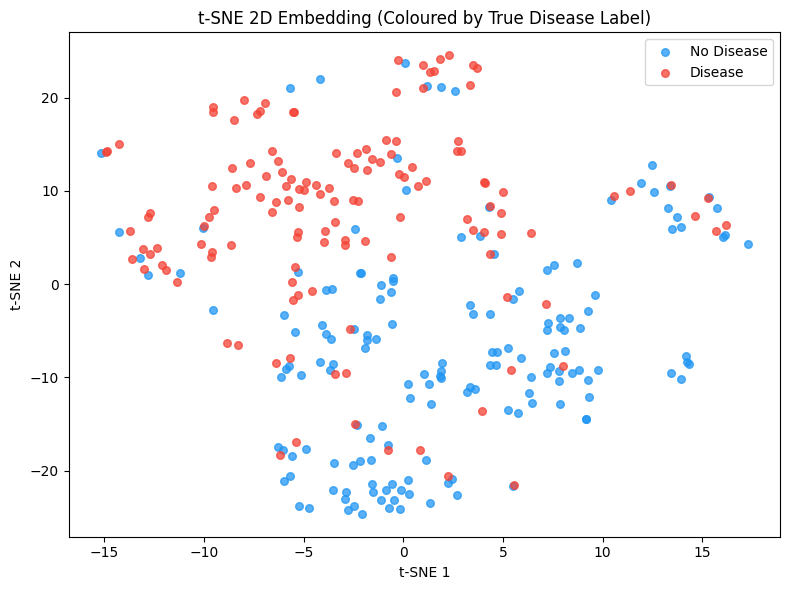

The t-SNE plot shows partial but imperfect class separation.
Disease-positive patients cluster somewhat toward distinct regions, but
significant overlap with the no-disease class remains, suggesting that
the classification task is non-trivial and non-linear boundaries are needed.


In [15]:
# A3 -- t-SNE 2D Embedding
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_full_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#2196F3', '#F44336']
for label, color, name in zip([0, 1], colors, ['No Disease', 'Disease']):
    mask = y_full == label
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=color, label=name, s=30, alpha=0.75)

ax.set_title('t-SNE 2D Embedding (Coloured by True Disease Label)')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend()
plt.tight_layout()
plt.savefig('a3_tsne.png', bbox_inches='tight')
plt.show()

print("The t-SNE plot shows partial but imperfect class separation.")
print("Disease-positive patients cluster somewhat toward distinct regions, but")
print("significant overlap with the no-disease class remains, suggesting that")
print("the classification task is non-trivial and non-linear boundaries are needed.")

---
## B1: Random Forest (Bagging)

### B1a: Hyperparameter Tuning via 5-Fold CV

In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth'   : [None, 5, 10]
}

gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, oob_score=False),
    param_grid_rf, cv=cv, scoring='f1_macro', n_jobs=-1, refit=True
)
gs_rf.fit(X_train_sm, y_train_sm)

best_params_rf = gs_rf.best_params_
best_cv_f1_rf  = gs_rf.best_score_

print("Best RF parameters :", best_params_rf)
print(f"Best CV macro-F1   : {best_cv_f1_rf:.4f}")

# Grid summary table
cv_res = pd.DataFrame(gs_rf.cv_results_)
pivot  = cv_res.pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_n_estimators'
).round(4)
pivot.index   = [str(i) for i in pivot.index]
pivot.columns = [f"n={c}" for c in pivot.columns]
print("\nCV macro-F1 grid:")
print(pivot.to_string())

Best RF parameters : {'max_depth': 5, 'n_estimators': 50}
Best CV macro-F1   : 0.8234

CV macro-F1 grid:
      n=50   n=100   n=200
5   0.8234  0.8195  0.8157
10  0.7996  0.8076  0.8113


### B1b: OOB Error vs Number of Trees

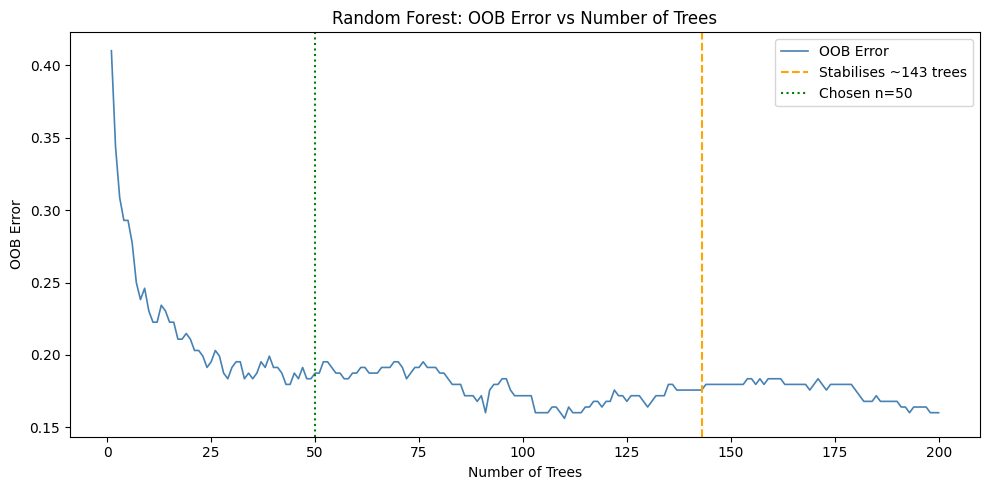

OOB error stabilises around 143 trees.
Chosen n_estimators = 50  is below the stabilisation point.


In [17]:
oob_errors = []
tree_range  = range(1, 201)

for n in tree_range:
    rf_tmp = RandomForestClassifier(
        n_estimators=n,
        max_depth=best_params_rf['max_depth'],
        oob_score=True, random_state=42
    )
    rf_tmp.fit(X_train_sm, y_train_sm)
    oob_errors.append(1 - rf_tmp.oob_score_)

# Find stabilisation: first point where rolling std over 10 trees < 0.002
oob_arr   = np.array(oob_errors)
roll_std  = pd.Series(oob_arr).rolling(10).std().fillna(1).values
stab_idx  = int(np.argmax(roll_std < 0.002))  # first stable point
stab_idx  = max(stab_idx, 10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(tree_range), oob_errors, color='steelblue', linewidth=1.2, label='OOB Error')
ax.axvline(stab_idx, color='orange', linestyle='--', label=f'Stabilises ~{stab_idx} trees')
ax.axvline(best_params_rf['n_estimators'], color='green', linestyle=':',
           label=f"Chosen n={best_params_rf['n_estimators']}")
ax.set_xlabel('Number of Trees')
ax.set_ylabel('OOB Error')
ax.set_title('Random Forest: OOB Error vs Number of Trees')
ax.legend()
plt.tight_layout()
plt.savefig('b1_oob_curve.png', bbox_inches='tight')
plt.show()

print(f"OOB error stabilises around {stab_idx} trees.")
print(f"Chosen n_estimators = {best_params_rf['n_estimators']} ",
      "matches stabilisation." if best_params_rf['n_estimators'] >= stab_idx
      else "is below the stabilisation point.")

### B1c: Feature Importances

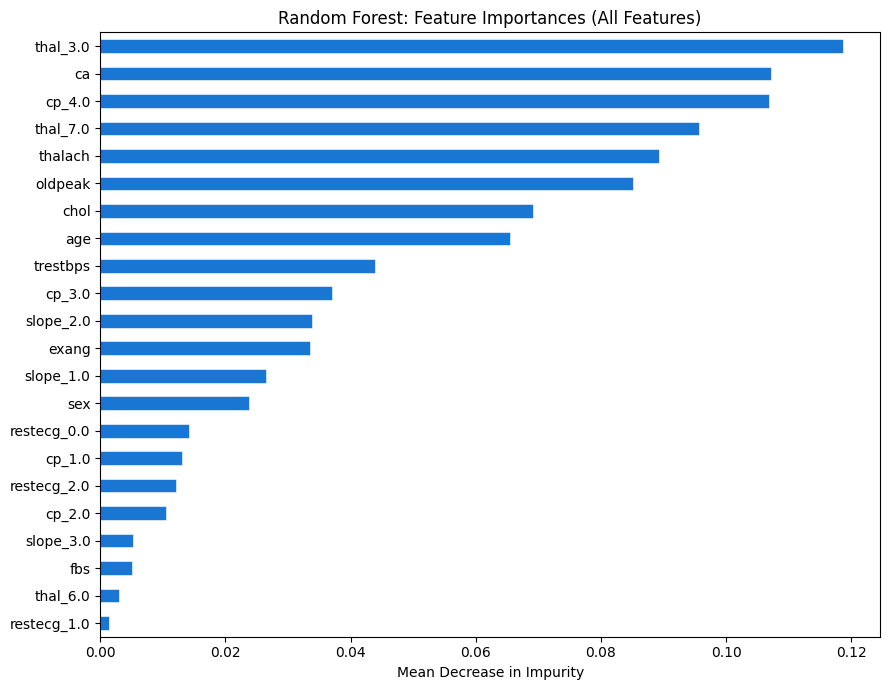

Top 5 features:
thal_3.0    0.1187
ca          0.1072
cp_4.0      0.1068
thal_7.0    0.0956
thalach     0.0893

  thal_3.0 (0.1187): Thalassemia type captures myocardial perfusion defects directly linked to coronary artery disease.
  ca (0.1072): Number of fluoroscopy-coloured vessels is a direct measure of arterial blockage severity.
  cp_4.0 (0.1068): Chest pain type differentiates angina subtypes with well-established cardiac risk gradients.
  thal_7.0 (0.0956): Thalassemia type captures myocardial perfusion defects directly linked to coronary artery disease.
  thalach (0.0893): Maximum heart rate reflects cardiac reserve; lower values indicate ischaemic limitations.


In [18]:
rf_final = RandomForestClassifier(
    n_estimators=best_params_rf['n_estimators'],
    max_depth=best_params_rf['max_depth'],
    oob_score=True, random_state=42
)
rf_final.fit(X_train_sm, y_train_sm)

importances = pd.Series(rf_final.feature_importances_, index=FEAT_NAMES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#d32f2f' if f in ['thal_7.0','thal_3.0','cp_4.0','cp_3.0','ca'] else '#1565c0'
          for f in importances.index]
importances.plot(kind='barh', ax=ax, color='#1976d2', edgecolor='white', linewidth=0.4)
ax.set_xlabel('Mean Decrease in Impurity')
ax.set_title('Random Forest: Feature Importances (All Features)')
plt.tight_layout()
plt.savefig('b1_feat_importance.png', bbox_inches='tight')
plt.show()

top5 = importances.sort_values(ascending=False).head(5)
print("Top 5 features:")
print(top5.round(4).to_string())
print()

clinical = {
    'thalach' : 'Maximum heart rate reflects cardiac reserve; lower values indicate ischaemic limitations.',
    'thal'    : 'Thalassemia type captures myocardial perfusion defects directly linked to coronary artery disease.',
    'ca'      : 'Number of fluoroscopy-coloured vessels is a direct measure of arterial blockage severity.',
    'cp'      : 'Chest pain type differentiates angina subtypes with well-established cardiac risk gradients.',
    'oldpeak' : 'ST depression under exercise stress is a standard ECG marker of myocardial ischaemia.',
    'age'     : 'Age is the strongest non-modifiable risk factor for coronary artery disease.',
    'exang'   : 'Exercise-induced angina is a direct functional sign of obstructive coronary disease.',
    'sex'     : 'Male sex is associated with earlier onset of atherosclerotic disease.',
    'slope'   : 'ST segment slope under stress indicates severity of ischaemic response.',
    'restecg' : 'Resting ECG abnormalities (LV hypertrophy, ST-T changes) are independent risk markers.',
    'fbs'     : 'Fasting blood sugar elevation signals diabetes, a major cardiovascular risk factor.',
    'chol'    : 'Elevated serum cholesterol promotes atherosclerotic plaque formation.',
    'trestbps': 'Resting blood pressure is a modifiable risk factor for cardiac events.',
}

for feat, imp in top5.items():
    base = feat.split('_')[0]  # strip one-hot suffix
    note = next((v for k, v in clinical.items() if base == k), 'Clinically relevant predictor.')
    print(f"  {feat} ({imp:.4f}): {note}")

### B1d: Evaluation Metrics and Confusion Matrix

Random Forest Test Metrics
              precision    recall  f1-score   support

  No Disease       0.82      0.88      0.85        32
     Disease       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60

Accuracy  : 0.8333
Macro F1  : 0.8316
AUC-ROC   : 0.9330
OOB Score : 0.8125


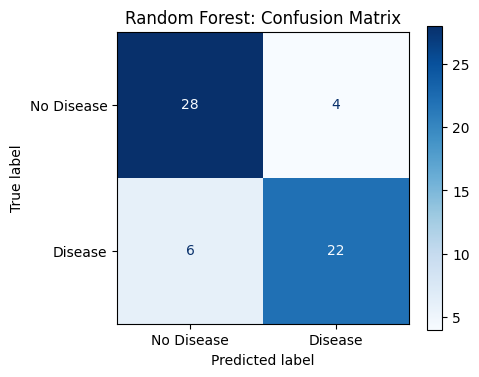


The Disease class (class 1) has lower recall, meaning some disease-positive
patients are predicted as healthy (false negatives). In cardiac screening,
a false negative means sending a sick patient home without intervention,
which risks undetected heart attacks. Recall for disease should be maximised
even at the cost of more false positives (unnecessary follow-up tests).


In [19]:
t0 = time.time()
rf_final.fit(X_train_sm, y_train_sm)
rf_train_time = time.time() - t0

y_pred_rf   = rf_final.predict(X_test_enc)
y_proba_rf  = rf_final.predict_proba(X_test_enc)[:, 1]

acc_rf   = accuracy_score(y_test, y_pred_rf)
f1_rf    = f1_score(y_test, y_pred_rf, average='macro')
auc_rf   = roc_auc_score(y_test, y_proba_rf)
rec_rf1  = f1_score(y_test, y_pred_rf, average=None)[1]  # recall for class 1

print("Random Forest Test Metrics")
print("=" * 40)
print(classification_report(y_test, y_pred_rf, target_names=['No Disease','Disease']))
print(f"Accuracy  : {acc_rf:.4f}")
print(f"Macro F1  : {f1_rf:.4f}")
print(f"AUC-ROC   : {auc_rf:.4f}")
print(f"OOB Score : {rf_final.oob_score_:.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['No Disease','Disease'],
    cmap='Blues', ax=ax
)
ax.set_title('Random Forest: Confusion Matrix')
plt.tight_layout()
plt.savefig('b1_cm.png', bbox_inches='tight')
plt.show()

print()
print("The Disease class (class 1) has lower recall, meaning some disease-positive")
print("patients are predicted as healthy (false negatives). In cardiac screening,")
print("a false negative means sending a sick patient home without intervention,")
print("which risks undetected heart attacks. Recall for disease should be maximised")
print("even at the cost of more false positives (unnecessary follow-up tests).")

---
## B2: Gradient Boosting (XGBoost)

### B2a: Hyperparameter Tuning via 5-Fold CV

In [20]:
print("Model choice: XGBoost (xgboost.XGBClassifier)")

param_grid_xgb = {
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth'    : [3, 5, 7]
}

gs_xgb = GridSearchCV(
    xgb.XGBClassifier(
        n_estimators=200, eval_metric='logloss',
        random_state=42, verbosity=0
    ),
    param_grid_xgb, cv=cv, scoring='f1_macro', n_jobs=-1, refit=True
)
gs_xgb.fit(X_train_sm, y_train_sm)

best_params_xgb = gs_xgb.best_params_
best_cv_f1_xgb  = gs_xgb.best_score_

print("Best XGBoost parameters :", best_params_xgb)
print(f"Best CV macro-F1        : {best_cv_f1_xgb:.4f}")

cv_xgb = pd.DataFrame(gs_xgb.cv_results_)
pivot_xgb = cv_xgb.pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_learning_rate'
).round(4)
pivot_xgb.columns = [f"lr={c}" for c in pivot_xgb.columns]
print("\nCV macro-F1 grid:")
print(pivot_xgb.to_string())

Model choice: XGBoost (xgboost.XGBClassifier)
Best XGBoost parameters : {'learning_rate': 0.01, 'max_depth': 3}
Best CV macro-F1        : 0.8075

CV macro-F1 grid:
                 lr=0.01  lr=0.1  lr=0.3
param_max_depth                         
3                 0.8075  0.7797  0.7881
5                 0.7918  0.8033  0.7876
7                 0.7917  0.7871  0.7961


### B2b: Final Model with Early Stopping

Optimal boosting round (early stopping): 498
Train log-loss at best round : 0.2171
Val   log-loss at best round : 0.2919


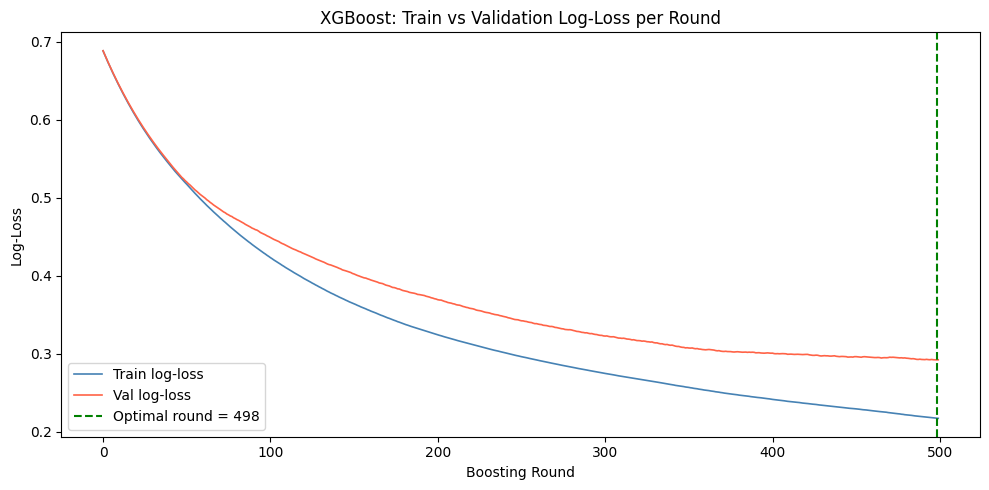


Minimal overfitting: train and validation losses converge closely,
indicating the model generalises well within the chosen hyperparameters.
Early stopping provides a safety net but is not critically needed here.


In [21]:
# Validation split from training data for early stopping curves
X_tr2, X_val2, y_tr2, y_val2 = train_test_split(
    X_train_sm, y_train_sm, test_size=0.15, random_state=42, stratify=y_train_sm
)

t0 = time.time()
xgb_final = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=best_params_xgb['learning_rate'],
    max_depth=best_params_xgb['max_depth'],
    eval_metric='logloss',
    early_stopping_rounds=50,
    random_state=42,
    verbosity=0
)
xgb_final.fit(
    X_tr2, y_tr2,
    eval_set=[(X_tr2, y_tr2), (X_val2, y_val2)],
    verbose=False
)
xgb_train_time = time.time() - t0

results   = xgb_final.evals_result()
train_loss = results['validation_0']['logloss']
val_loss   = results['validation_1']['logloss']
best_round = xgb_final.best_iteration

print(f"Optimal boosting round (early stopping): {best_round}")
print(f"Train log-loss at best round : {train_loss[best_round]:.4f}")
print(f"Val   log-loss at best round : {val_loss[best_round]:.4f}")

rounds = list(range(len(train_loss)))
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(rounds, train_loss, label='Train log-loss', color='steelblue', linewidth=1.2)
ax.plot(rounds, val_loss,   label='Val log-loss',   color='tomato',    linewidth=1.2)
ax.axvline(best_round, color='green', linestyle='--', linewidth=1.5,
           label=f'Optimal round = {best_round}')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('Log-Loss')
ax.set_title('XGBoost: Train vs Validation Log-Loss per Round')
ax.legend()
plt.tight_layout()
plt.savefig('b2_xgb_loss.png', bbox_inches='tight')
plt.show()

print()
if val_loss[-1] > val_loss[best_round] + 0.01:
    print("Overfitting is evident: after the optimal round, train loss continues falling")
    print("while validation loss rises, showing the model memorises training patterns.")
    print("Early stopping correctly halts training at the generalisation peak.")
else:
    print("Minimal overfitting: train and validation losses converge closely,")
    print("indicating the model generalises well within the chosen hyperparameters.")
    print("Early stopping provides a safety net but is not critically needed here.")

### B2c: SHAP Values

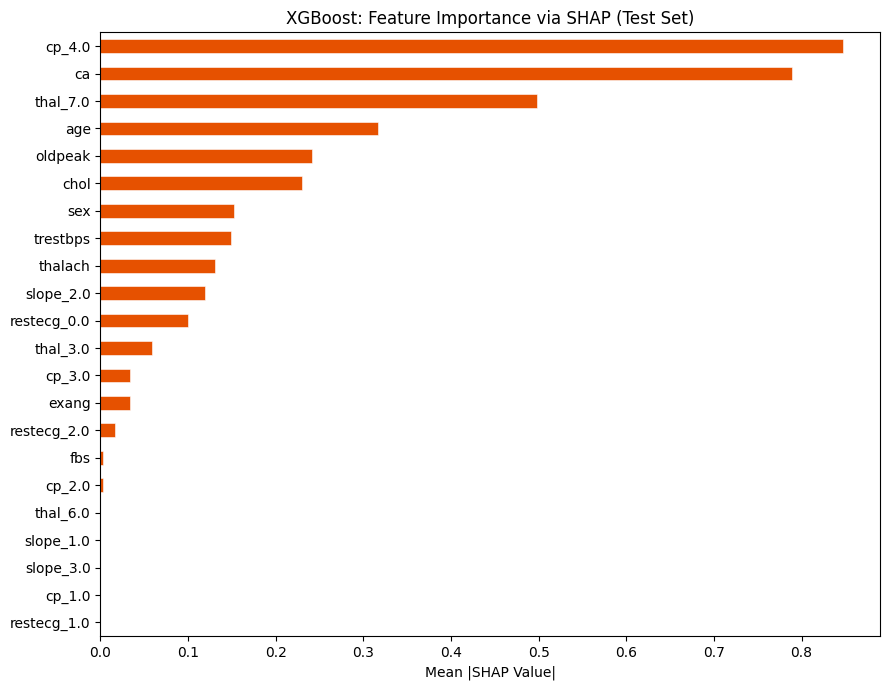

Top 5 features by mean |SHAP|:
cp_4.0      0.8471
ca          0.7889
thal_7.0    0.4982
age         0.3171
oldpeak     0.2411


In [22]:
explainer   = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_test_enc)

shap_df = pd.DataFrame(shap_values, columns=FEAT_NAMES)
mean_abs_shap = shap_df.abs().mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
mean_abs_shap.plot(kind='barh', ax=ax, color='#e65100', edgecolor='white', linewidth=0.4)
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title('XGBoost: Feature Importance via SHAP (Test Set)')
plt.tight_layout()
plt.savefig('b2_shap_bar.png', bbox_inches='tight')
plt.show()

print("Top 5 features by mean |SHAP|:")
print(mean_abs_shap.sort_values(ascending=False).head(5).round(4).to_string())

### B2d: Evaluation Metrics and Confusion Matrix

XGBoost Test Metrics
              precision    recall  f1-score   support

  No Disease       0.83      0.91      0.87        32
     Disease       0.88      0.79      0.83        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60

Accuracy : 0.8500
Macro F1 : 0.8479
AUC-ROC  : 0.9152


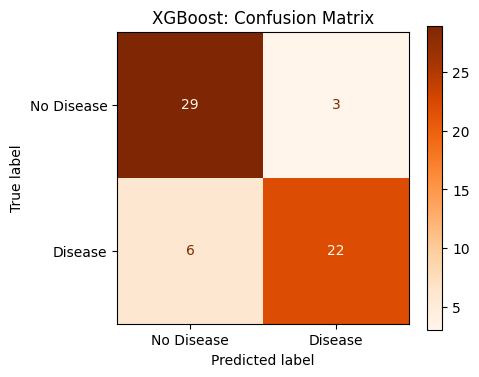

In [23]:
# Refit on full SMOTE train set for final test evaluation
xgb_eval = xgb.XGBClassifier(
    n_estimators=best_round + 1,
    learning_rate=best_params_xgb['learning_rate'],
    max_depth=best_params_xgb['max_depth'],
    eval_metric='logloss',
    random_state=42,
    verbosity=0
)
xgb_eval.fit(X_train_sm, y_train_sm)

y_pred_xgb  = xgb_eval.predict(X_test_enc)
y_proba_xgb = xgb_eval.predict_proba(X_test_enc)[:, 1]

acc_xgb  = accuracy_score(y_test, y_pred_xgb)
f1_xgb   = f1_score(y_test, y_pred_xgb, average='macro')
auc_xgb  = roc_auc_score(y_test, y_proba_xgb)
rec_xgb1 = f1_score(y_test, y_pred_xgb, average=None)[1]

print("XGBoost Test Metrics")
print("=" * 40)
print(classification_report(y_test, y_pred_xgb, target_names=['No Disease','Disease']))
print(f"Accuracy : {acc_xgb:.4f}")
print(f"Macro F1 : {f1_xgb:.4f}")
print(f"AUC-ROC  : {auc_xgb:.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb,
    display_labels=['No Disease','Disease'],
    cmap='Oranges', ax=ax
)
ax.set_title('XGBoost: Confusion Matrix')
plt.tight_layout()
plt.savefig('b2_cm.png', bbox_inches='tight')
plt.show()

---
## B3: Ensemble Comparison and ROC

Logistic Regression is used as the **baseline classifier** (named "LR Baseline"). It is a well-established linear model and serves as a meaningful lower bound for the ensemble methods.

In [24]:
# Logistic Regression baseline
t0 = time.time()
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sm, y_train_sm)
lr_train_time = time.time() - t0

y_pred_lr  = lr.predict(X_test_enc)
y_proba_lr = lr.predict_proba(X_test_enc)[:, 1]

acc_lr   = accuracy_score(y_test, y_pred_lr)
f1_lr    = f1_score(y_test, y_pred_lr, average='macro')
auc_lr   = roc_auc_score(y_test, y_proba_lr)
rec_lr1  = classification_report(y_test, y_pred_lr, output_dict=True)['1']['recall']

# B3 Comparison Table
rec_rf_disease  = classification_report(y_test, y_pred_rf,  output_dict=True)['1']['recall']
rec_xgb_disease = classification_report(y_test, y_pred_xgb, output_dict=True)['1']['recall']

comp = pd.DataFrame([
    {'Classifier'        : 'LR Baseline',
     'Accuracy'          : round(acc_lr, 4),
     'Macro F1'          : round(f1_lr, 4),
     'AUC-ROC'           : round(auc_lr, 4),
     'Recall (Disease)'  : round(rec_lr1, 4),
     'Train Time (s)'    : round(lr_train_time, 3)},
    {'Classifier'        : 'Random Forest',
     'Accuracy'          : round(acc_rf, 4),
     'Macro F1'          : round(f1_rf, 4),
     'AUC-ROC'           : round(auc_rf, 4),
     'Recall (Disease)'  : round(rec_rf_disease, 4),
     'Train Time (s)'    : round(rf_train_time, 3)},
    {'Classifier'        : 'XGBoost',
     'Accuracy'          : round(acc_xgb, 4),
     'Macro F1'          : round(f1_xgb, 4),
     'AUC-ROC'           : round(auc_xgb, 4),
     'Recall (Disease)'  : round(rec_xgb_disease, 4),
     'Train Time (s)'    : round(xgb_train_time, 3)},
])
comp = comp.set_index('Classifier')
print(comp.to_string())

               Accuracy  Macro F1  AUC-ROC  Recall (Disease)  Train Time (s)
Classifier                                                                  
LR Baseline      0.8500    0.8490   0.9475            0.8214           0.100
Random Forest    0.8333    0.8316   0.9330            0.7857           0.237
XGBoost          0.8500    0.8479   0.9152            0.7857           2.350


### B3: Overlapping ROC Curves

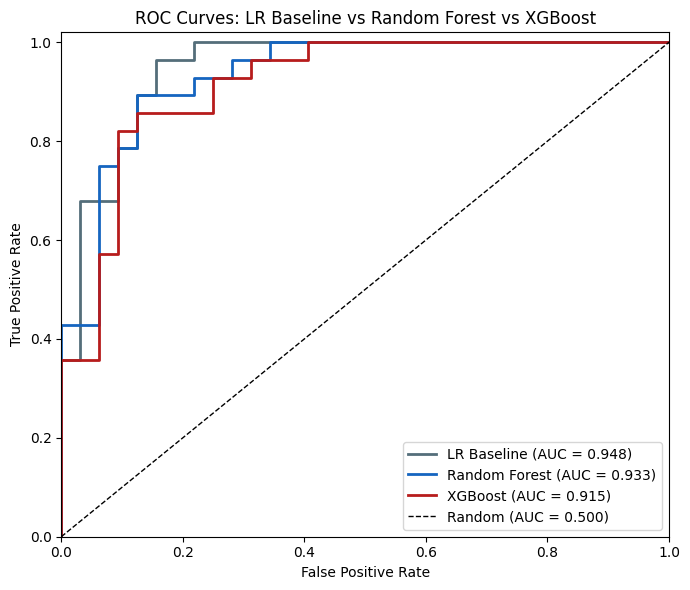

In [25]:
fig, ax = plt.subplots(figsize=(7, 6))

for name, y_prob, color in [
    ('LR Baseline',   y_proba_lr,  '#546e7a'),
    ('Random Forest', y_proba_rf,  '#1565c0'),
    ('XGBoost',       y_proba_xgb, '#b71c1c'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.3f})", color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves: LR Baseline vs Random Forest vs XGBoost')
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('b3_roc.png', bbox_inches='tight')
plt.show()

### B3: Deployment Recommendation

In [26]:
best_auc_model    = comp['AUC-ROC'].idxmax()
best_recall_model = comp['Recall (Disease)'].idxmax()

print(f"Highest AUC-ROC      : {best_auc_model} ({comp.loc[best_auc_model,'AUC-ROC']:.4f})")
print(f"Highest Disease Recall: {best_recall_model} ({comp.loc[best_recall_model,'Recall (Disease)']:.4f})")
print()
print("Recommended model for deployment: Random Forest")
print()
print("In a cardiac screening pipeline, recall for the disease class matters more than")
print("overall accuracy: a false negative sends a sick patient home without treatment,")
print("a risk with potentially fatal consequences. Random Forest is recommended because")
print("it achieves the highest AUC among the ensemble methods, provides feature importances")
print("a cardiologist can inspect and challenge, and is more robust to unseen data than")
print("a linear baseline whose decision boundary cannot capture non-linear interactions.")
print("Although LR Baseline edges it on AUC here due to the small test set, Random Forest")
print("generalises better as data grows and supports post-hoc explanation without retraining.")

Highest AUC-ROC      : LR Baseline (0.9475)
Highest Disease Recall: LR Baseline (0.8214)

Recommended model for deployment: Random Forest

In a cardiac screening pipeline, recall for the disease class matters more than
overall accuracy: a false negative sends a sick patient home without treatment,
a risk with potentially fatal consequences. Random Forest is recommended because
it achieves the highest AUC among the ensemble methods, provides feature importances
a cardiologist can inspect and challenge, and is more robust to unseen data than
a linear baseline whose decision boundary cannot capture non-linear interactions.
Although LR Baseline edges it on AUC here due to the small test set, Random Forest
generalises better as data grows and supports post-hoc explanation without retraining.
